In [143]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d
import time as _time

FILE_PATH = os.getcwd()
sys.path.append(os.path.join(FILE_PATH, '..'))
import plot_settings
plot_settings.apply()

COLORS    = plot_settings.colors()
DATA_DIR  = os.path.join(FILE_PATH, 'Multi_data')
DATA_FILE = os.path.join(DATA_DIR, '2_merged_data.txt')
DT        = 1.0

PULSE_FILE  = os.path.join(DATA_DIR, 'data_pulse1.txt')
SAVE_FIGS   = False
SAVE_PULSE_FIGS = False

Q0          = 17921.57581



print("Loading data...")
data = pd.read_csv(DATA_FILE, sep=';', comment='%')
print(data.columns)
data['eta'] = -data['eta']
I_MAX = data['I'].max()

pulse_raw = pd.read_csv(PULSE_FILE, sep=',', comment='%')
print(pulse_raw.columns)
pulse_raw['eta'] = pulse_raw['eta']

def prepare_pulse_data(pulse_raw):
    pulse_trajs = []
    for _, grp in pulse_raw.sort_values(['trajectory', 't']).groupby('trajectory'):
        grp = grp.reset_index(drop=True)
        pulse_trajs.append(dict(
            I     = grp['I'].values,
            u     = float(grp['u'].iloc[0]),
            soc0  = float(grp['soc'].iloc[0]),
            T     = len(grp),
            t     = grp['t'].values,
            V     = grp['V'].values,
            F     = grp['F'].values,
            soc   = grp['soc'].values,
            c     = grp['C'].values.astype(np.float32),
            eta   = grp['eta'].values.astype(np.float32),
            Ue   = grp['Ue'].values,
        ))
    return pulse_trajs

pulse_trajs = prepare_pulse_data(pulse_raw)

import GP
GP_FIT = GP.GP_process()

Loading data...
Index(['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'eta', 'trajectory', 'dV',
       'dF', 'soc'],
      dtype='object')
Index(['u_par', 'C', 't', 'V', 'F', 'u', 'Ue', 'soc', 'I', 'trajectory',
       'eta'],
      dtype='object')


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [161]:
# ── Load data ──────────────────────────────────────────────
data = pd.read_csv(DATA_FILE, sep=';', comment='%')
data['eta'] = -data['eta']

# Build OCV interpolator from data (same as battery models)
_s, _u = data['soc'].values, data['Ue'].values
_i = np.argsort(_s)
Ue_interp = interp1d(_s[_i], _u[_i], kind='linear', fill_value='extrapolate')

print(f"  {len(data)} pts, {data['trajectory'].nunique()} trajectories")

# ── Build trajectories ─────────────────────────────────────
def prepare_data(data):
    trajs = []
    for _, grp in data.sort_values(['trajectory', 't']).groupby('trajectory'):
        grp = grp.reset_index(drop=True)
        I_val, u_val = float(grp['I'].iloc[0]), float(grp['u'].iloc[0])
        soc_arr = grp['soc'].values.astype(np.float32)
        trajs.append(dict(
            I     = grp['I'].values,
            u     = float(grp['u'].iloc[0]),
            soc0  = float(grp['soc'].iloc[0]),
            T     = len(grp),
            t     = grp['t'].values,
            V     = grp['V'].values,
            F     = grp['F'].values,
            soc   = grp['soc'].values,
            c     = grp['C'].values.astype(np.float32),
            eta   = grp['eta'].values.astype(np.float32),
            Ue   = grp['Ue'].values,
            u_par = float(grp['u_par'].iloc[0]),
        ))
    return trajs

trajs = prepare_data(data)
print(f"  {len(trajs)} trajectories prepared")

  415557 pts, 248 trajectories
  248 trajectories prepared


In [145]:
# --- ODE solver---
def simulate_ode(t, i_profile, ocv, p):
    """
    t          : 1-D time array (s)
    i_profile  : 1-D current array, same length as t
    ocv        : 1-D open circuit voltage array, same length as t
    """
    def current(t_scalar):
        return np.interp(t_scalar, t, i_profile)

    def dU1(u, t_s):               # RC voltage ODE
        return -u / (p['R1'] * p['C1']) + current(t_s) / p['C1']

    def dSOC(z, t_s):              # SOC ODE
        return -current(t_s) / p['Q']

    U1  = scipy.integrate.odeint(dU1,  0.0, t, args=()).flatten()
    soc = scipy.integrate.odeint(dSOC, 1.0, t, args=()).flatten()

    V   = ocv - i_profile * p['R0'] - U1
    return V, soc, U1

In [146]:
LIMS = {
    'R0': (0.001, 0.1),   # Ohm
    'R1': (0.001, 0.25),   # Ohm
    'C1': (100, 2.5e4),   # F
    'R2': (0.001, 0.1),   # Ohm
    'C2': (100, 1e4),   # F
}

In [147]:
def ECM_solve_tau(theta, i, t):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t,tau,gamma):
        I_t = I_interp(t)
        return -u / tau + I_t * gamma

    # Solve ODE
    R0, tau , gamma = theta
    U1 = scipy.integrate.odeint(dU, 0.0, t, args=(tau,gamma)).flatten()
    #U2 = 0

    U = U1 
    # Voltage model
    eta_model =  i*R0 + U

    return eta_model

def ECM_solve_du(theta, i, t, RC2 = False, U0 = 0):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C 

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU, U0, t, args=(theta[1],theta[2])).flatten()

    if RC2:
        U2 = scipy.integrate.odeint(dU, U0, t, args=(theta[3],theta[4])).flatten()
    else: 
        U2 = 0
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model =  i*theta[0] + U

    return eta_model


def ECM_solve(theta, i, t):
    R0, R1 , C1 = theta

    eta_model = i * (R0 + R1 * (1 - np.exp(-t/(R1*C1))))
    return eta_model

def ECM_solve_curvefit(x, R0, R1, C1):
    t, i = x
    eta_model = ECM_solve_du(theta=[R0, R1, C1], i=i, t=t)
    return eta_model

def dSOC_dt(z,t, i):              # SOC ODE
    return  -i / Q0


In [148]:
def parameter_estimation_curvefit(tr, p0=[0.01, 0.01, 1500],lims = LIMS, U0 = 0):
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]], [lims['R0'][1], lims['R1'][1], lims['C1'][1]])

    xdata = [tr['t'], tr['I']]
    ydata = tr['eta']
    popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)
    R0, R1 , C1 = popt
    eta = ECM_solve_curvefit(xdata, R0, R1, C1)
    return R0, R1, C1,eta

R0 estimate: 0.0083 Ohm


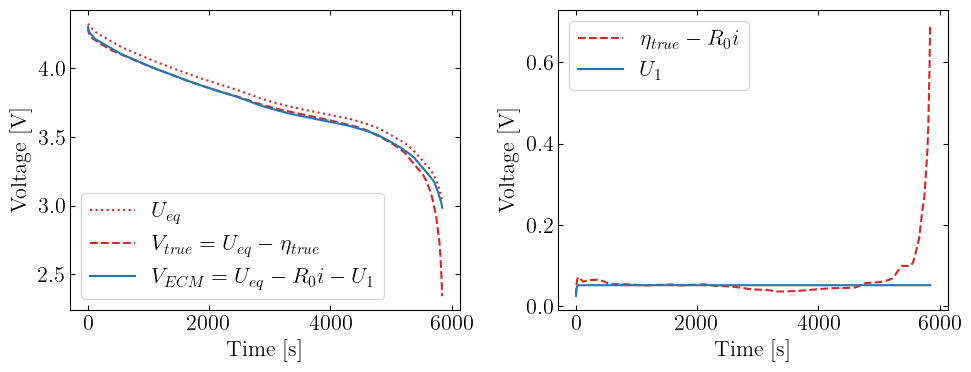

In [152]:
idx = 2
traj = trajs[idx]   # Just take the first trajectory for testing

tr = pd.DataFrame(traj)  # Convert to DataFrame for easier handling

#tr = tr[tr['t'] < 600]  # Limit to first 200 seconds for better visualization
#tr 

def R0_func(u, I):
    return u * (-0.0001887521) - 7.049519e-5 * I + 0.008446693

print(f"R0 estimate: {R0_func(tr['u'], tr['I'])[10]:.4f} Ohm")
params = dict(
    R0=R0_func(tr['u'], tr['I']),
    R1=0.009,
    C1=1000,
    Q=17921.57581,       # match Q0 from the battery models
)

eta = ECM_solve_du(theta=[params['R0'], params['R1'], params['C1']], i=tr['I'], t=tr['t'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(tr['t'], GP.soc_to_Ue(tr['soc'], GP_FIT), color=COLORS[1], linestyle=':', label=r'$U_{eq}$')
axes[0].plot(tr['t'], tr['V'], color=COLORS[1], linestyle='--', label=r'$V_{true} = U_{eq} - \eta_{true}$')
axes[0].plot(tr['t'], -eta + tr['Ue'], color=COLORS[0], label=r'$V_{ECM} = U_{eq} - R_0 i - U_1$')
axes[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Voltage [V]'); axes[0].legend()

axes[1].plot(tr['t'], tr['eta'] , color=COLORS[1], linestyle='--', label=r'$\eta_{true} - R_0i$')
axes[1].plot(tr['t'], eta, color=COLORS[0], label=r'$U_1$')
axes[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Voltage [V]'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FILE_PATH, 'ecm_ode.pdf'), bbox_inches='tight')

In [153]:
start_time = _time.perf_counter()
R0, R1, C1, eta_1 = parameter_estimation_curvefit(tr)
end_time = _time.perf_counter()
print(f"Parameter estimation took {(end_time - start_time):.2f} seconds")
print(f"Estimated parameters for trajectory: R0={R0:.4f} Ohm, R1={R1:.4f} Ohm, C1={C1:.2f} F")

Parameter estimation took 0.07 seconds
Estimated parameters for trajectory: R0=0.0082 Ohm, R1=0.0127 Ohm, C1=430.19 F


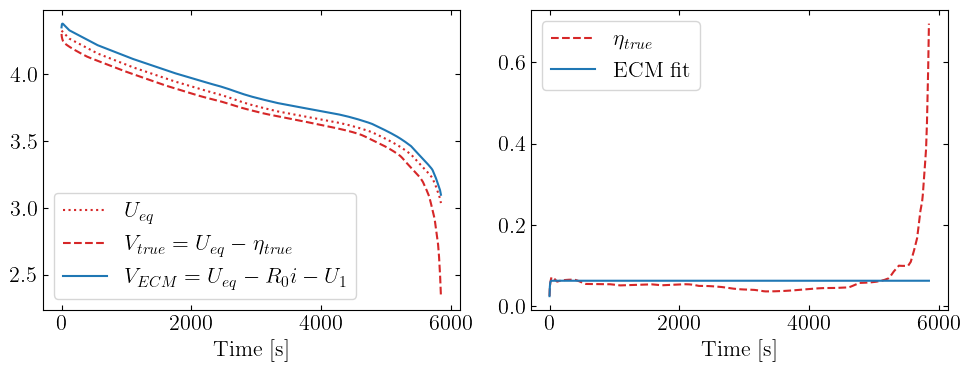

In [155]:
f, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(tr['t'], tr['Ue'], color=COLORS[1], linestyle=':', label=r'$U_{eq}$')
ax[0].plot(tr['t'], tr['V'], color=COLORS[1], linestyle='--', label=r'$V_{true} = U_{eq} - \eta_{true}$')
ax[0].plot(tr['t'], eta_1 + tr['Ue'], color=COLORS[0], label=r'$V_{ECM} = U_{eq} - R_0 i - U_1$')
ax[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Voltage [V]'); axes[0].legend() 

ax[1].plot(tr['t'], tr['eta'] , color=COLORS[1], linestyle='--', label=r'$\eta_{true}$')
ax[1].plot(tr['t'], eta_1, color=COLORS[0], label=r'ECM fit ')
ax[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Voltage [V]'); axes[1].legend()
for a in ax:
    a.legend()

plt.tight_layout()
#plt.plot(tr['t'], eta_1, label='ECM Fit 1RC', color=COLORS[0])
#plt.plot(tr['t'], -tr['eta'], label='Data', color=COLORS[1], ls = '--')

In [94]:
# def ECM_solve_curvefit_2RC(x, R0, R1, C1, R2, C2):
#     t, i = x
#     eta_model = ECM_solve_du(theta=[R0, R1, C1, R2,C2], i=i, t=t, RC2=True)
#     return eta_model


# def parameter_estimation_curvefit_2RC(tr, p0=[0.01, 0.01, 1500, 0.01, 1500], lims=LIMS):
#     bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0], lims['R2'][0], lims['C2'][0]], 
#               [lims['R0'][1], lims['R1'][1], lims['C1'][1], lims['R2'][1], lims['C2'][1]])

#     xdata = [tr['t'], tr['I']]
#     ydata = -tr['eta']
#     popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit_2RC, xdata, ydata, p0=p0, bounds=bounds)
#     R0, R1 , C1, R2, C2 = popt
#     eta = ECM_solve_curvefit_2RC(xdata, R0, R1, C1, R2, C2)
#     return R0, R1, C1, R2, C2, eta

In [95]:
#R0, R1, C1, R2, C2, eta_2 = parameter_estimation_curvefit_2RC(tr, p0=[0.01, 0.01, 1500, 0.01, 1500], lims=LIMS)
#print(f"Estimated parameters for trajectory\nR0={R0:.4f} Ohm,\nR1={R1:.4f} Ohm,\nC1={C1:.2f} F,\nR2={R2:.4f} Ohm,\nC2={C2:.2f} F")

In [162]:
rmse = np.zeros(len(trajs))
I = np.zeros(len(trajs)) 
u = np.zeros(len(trajs))
for i,tr in enumerate(trajs):
    R0, R1, C1, eta_1 = parameter_estimation_curvefit(tr)
    rmse[i] = np.sqrt(np.mean((eta_1 - (tr['eta']))**2))
    I[i] = tr['c'].max()
    u[i] = tr['u_par']
    
    print(f"Estimated parameters for trajectory\nR0={R0:.4f} Ohm,\nR1={R1:.4f} Ohm,\nC1={C1:.2f} F")



Estimated parameters for trajectory
R0=0.0128 Ohm,
R1=0.0055 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0113 Ohm,
R1=0.0088 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0082 Ohm,
R1=0.0127 Ohm,
C1=430.19 F
Estimated parameters for trajectory
R0=0.0088 Ohm,
R1=0.0120 Ohm,
C1=454.92 F
Estimated parameters for trajectory
R0=0.0116 Ohm,
R1=0.0087 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0091 Ohm,
R1=0.0104 Ohm,
C1=604.61 F
Estimated parameters for trajectory
R0=0.0100 Ohm,
R1=0.0100 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0142 Ohm,
R1=0.0044 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0131 Ohm,
R1=0.0056 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0116 Ohm,
R1=0.0072 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0108 Ohm,
R1=0.0085 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0102 Ohm,
R1=0.0094 Ohm,
C1=25000.00 F
Estimated parameters for trajectory
R0=0.0130 

Text(0, 0.5, 'Frequency')

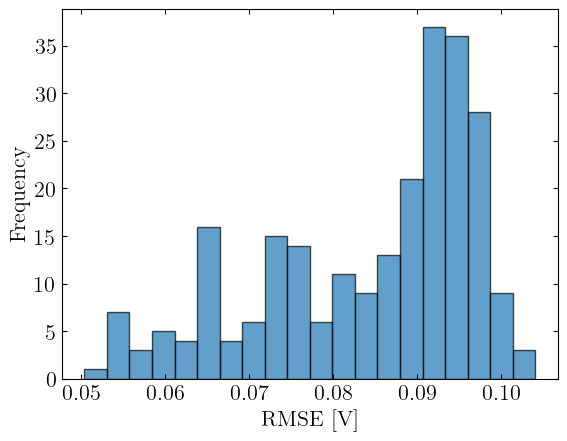

In [163]:
plt.hist(rmse, bins=20, color=COLORS[0], edgecolor='black', alpha = 0.7)
plt.xlabel('RMSE [V]')
plt.ylabel('Frequency')

0.08432149415563923


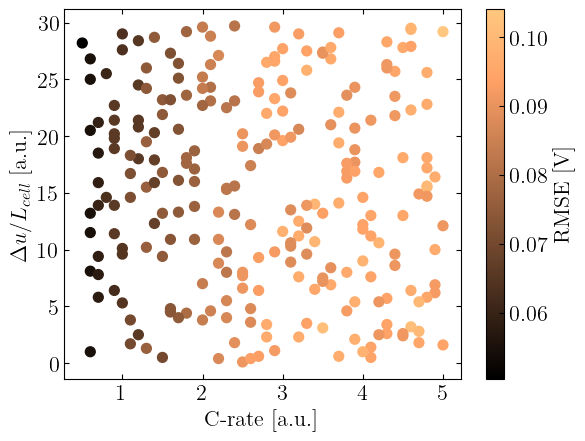

In [167]:
plt.scatter(I,u, marker='o', c = rmse, cmap='copper',s = 50)
plt.xlabel('C-rate [a.u.]')
plt.ylabel(r'$\Delta u / L_{cell}$ [a.u.]')
plt.colorbar(label = r'RMSE [V]')
plt.savefig(os.path.join(FILE_PATH, 'ecm_rmse_scatter.pdf'), bbox_inches='tight')
print(rmse.mean())

In [ ]:

# results = []
# for i, ptr in enumerate(pulse_trajs):
#     ptr = pd.DataFrame(ptr)
#     t_t_max = ptr['t'].max()
#     C_max = ptr['c'].max()

#     segment_length = 300
#     n_segments = int(np.ceil(t_t_max / segment_length))

#     for j in range(n_segments):
#         start = j * segment_length
#         end = min((j + 1) * segment_length, t_t_max)

#         t_t = ptr[(ptr['t'] > start) & (ptr['t'] < end)].copy()

#         if len(t_t) == 0:
#             continue

#         t_t['t'] = np.arange(len(t_t))

#         R0, R1, C1, eta_1 = parameter_estimation_curvefit(
#             t_t,
#             U0=-t_t['eta'].values[0]
#         )
#         results.append({
#             'trajectory': i,
#             'segment': j,
#             'C-max': C_max,
#             'R0': R0,
#             'R1': R1,
#             'C1': C1,
#             'soc': t_t['soc'].values.mean()})
        
# results_df = pd.DataFrame(results)
# print(results_df.head())
    

   trajectory  segment  C-max        R0        R1           C1       soc
0           0        0    1.9  0.012230  0.005584  2206.535551  0.920836
1           0        1    1.9  0.010000  0.010000  1500.000000  0.841672
2           0        2    1.9  0.008917  0.008065  5282.565530  0.762503
3           0        3    1.9  0.010000  0.010000  1500.000000  0.683340
4           0        4    1.9  0.007110  0.007708  2315.730841  0.604172


In [159]:

results = []
for i, ptr in enumerate(trajs):
    ptr = pd.DataFrame(ptr)
    SOC_min = ptr['soc'].min()
    C_max = ptr['c'].max()
    d_soc = ptr['soc'].max() - ptr['soc'].min()

    segment_length = 0.05
    n_segments = int(np.ceil(d_soc / segment_length))
    print(f'Traj {i}, n_segments: {n_segments}')

    for j in range(n_segments):
        start = j * segment_length
        end = min((j + 1) * segment_length, SOC_min + d_soc)

        t_t = ptr[(ptr['soc'] > start) & (ptr['soc'] < end)].copy()

        if len(t_t) == 0:
            continue

        t_t['t'] = np.arange(len(t_t))

        R0, R1, C1, eta_1 = parameter_estimation_curvefit(
            t_t,
            U0=-t_t['eta'].values[0]
        )
        results.append({
            'trajectory': i,
            'segment': j,
            'C-max': C_max,
            'R0': R0,
            'R1': R1,
            'C1': C1,
            'soc': t_t['soc'].values.mean()})
     

Traj 0, n_segments: 19
Traj 1, n_segments: 17
Traj 2, n_segments: 20
Traj 3, n_segments: 20
Traj 4, n_segments: 17
Traj 5, n_segments: 20
Traj 6, n_segments: 16
Traj 7, n_segments: 19
Traj 8, n_segments: 18
Traj 9, n_segments: 18
Traj 10, n_segments: 18
Traj 11, n_segments: 17
Traj 12, n_segments: 18
Traj 13, n_segments: 20
Traj 14, n_segments: 20
Traj 15, n_segments: 19
Traj 16, n_segments: 18
Traj 17, n_segments: 17
Traj 18, n_segments: 18
Traj 19, n_segments: 18
Traj 20, n_segments: 16
Traj 21, n_segments: 18
Traj 22, n_segments: 19
Traj 23, n_segments: 20
Traj 24, n_segments: 17
Traj 25, n_segments: 20
Traj 26, n_segments: 17
Traj 27, n_segments: 16
Traj 28, n_segments: 17
Traj 29, n_segments: 18
Traj 30, n_segments: 19
Traj 31, n_segments: 19
Traj 32, n_segments: 18


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_6335/1462158449.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)


Traj 33, n_segments: 19
Traj 34, n_segments: 17
Traj 35, n_segments: 18
Traj 36, n_segments: 16
Traj 37, n_segments: 16
Traj 38, n_segments: 17
Traj 39, n_segments: 19
Traj 40, n_segments: 19
Traj 41, n_segments: 16
Traj 42, n_segments: 19
Traj 43, n_segments: 17
Traj 44, n_segments: 19
Traj 45, n_segments: 18
Traj 46, n_segments: 18
Traj 47, n_segments: 17
Traj 48, n_segments: 19
Traj 49, n_segments: 16
Traj 50, n_segments: 20
Traj 51, n_segments: 17
Traj 52, n_segments: 20
Traj 53, n_segments: 19
Traj 54, n_segments: 17
Traj 55, n_segments: 18
Traj 56, n_segments: 16
Traj 57, n_segments: 17
Traj 58, n_segments: 20
Traj 59, n_segments: 20
Traj 60, n_segments: 18
Traj 61, n_segments: 17
Traj 62, n_segments: 19
Traj 63, n_segments: 19
Traj 64, n_segments: 17
Traj 65, n_segments: 20
Traj 66, n_segments: 17
Traj 67, n_segments: 17
Traj 68, n_segments: 16
Traj 69, n_segments: 20
Traj 70, n_segments: 18
Traj 71, n_segments: 19
Traj 72, n_segments: 19
Traj 73, n_segments: 17
Traj 74, n_segme

RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [ ]:
results_df = pd.DataFrame(results)
print(results_df.head())

   trajectory  segment  C-max        R0        R1           C1       soc
0           0        0    1.9  0.012230  0.005584  2206.535551  0.920836
1           0        1    1.9  0.010000  0.010000  1500.000000  0.841672
2           0        2    1.9  0.008917  0.008065  5282.565530  0.762503
3           0        3    1.9  0.010000  0.010000  1500.000000  0.683340
4           0        4    1.9  0.007110  0.007708  2315.730841  0.604172


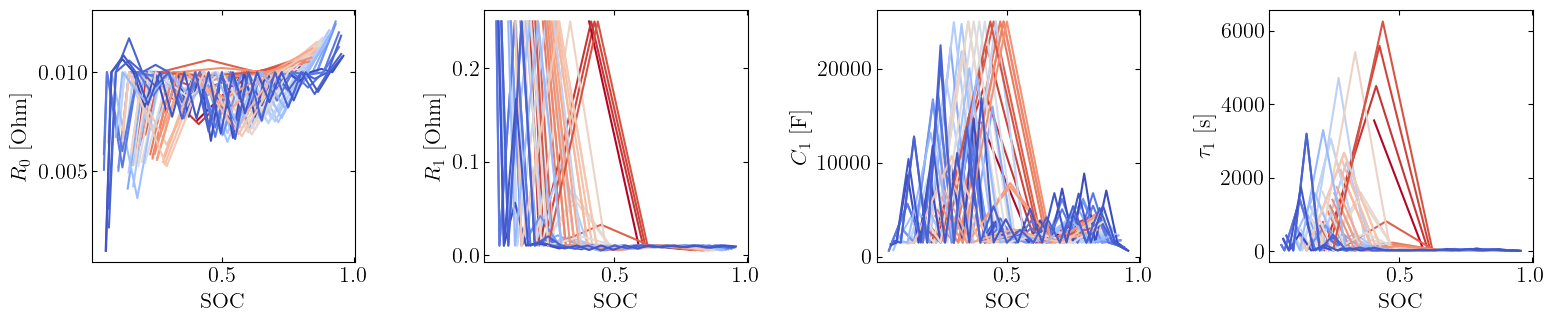

In [ ]:
import matplotlib as mpl
df = results_df
cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=df['C-max'].min(), vmax=df['C-max'].max())
f,axs = plt.subplots(1,4,figsize=(16,3.5), sharex=True)
for i in df['trajectory'].unique():
    mean_I = df.loc[df['trajectory'] == i, 'C-max'].mean()
    color = cmap(norm(mean_I))
    
    if i < 10:
        pass
    else:
        axs[0].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)),'R0'],
            color=color
        )
        axs[1].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)),'R1'],
            color=color
        )
        axs[2].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)),'C1'],
            color=color
        )
        axs[3].plot(
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)), 'soc'],
            df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)),'C1'] * df.loc[(df['trajectory'] == i) & ((df['C-max'] < 4.95)),'R1'],
            color=color
        )


for a in axs:
    a.set_xlabel('SOC')
    a.invert_xaxis()


axs[0].set_ylabel('$R_0$ [Ohm]')
axs[1].set_ylabel('$R_1$ [Ohm]')
axs[2].set_ylabel('$C_1$ [F]')
axs[3].set_ylabel(r'$\tau_1$ [s]')
plt.tight_layout()

In [ ]:
# plt.plot(rmse, marker='o')